## Setup & Installation



In [73]:
# ============================================
# SETUP & INSTALLATION
# ============================================

# Install required packages
!pipx install -q ultralytics roboflow

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import glob
import random
import yaml
from pathlib import Path
from collections import Counter

# YOLO imports
from ultralytics import YOLO

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Verify environment
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected — training will be slow!")
    print("Go to: Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.10.0.dev20251124+cu128
CUDA available: True
GPU device: NVIDIA GeForce RTX 5080


'pipx' is not recognized as an internal or external command,
operable program or batch file.


## Importing dataset from Roboflow

In [74]:
from roboflow import Roboflow

rf = Roboflow(api_key="yQJvIZ70VBxNEFuKOEg3")
project = rf.workspace("yousef-ghanem-jzj4y").project("brain-tumor-detection-fpf1f")
version = project.version(1)
dataset = version.download("yolov8")
DATASET_DIR = dataset.location

loading Roboflow workspace...
loading Roboflow project...


##  Load Pre-trained YOLO26 

In [75]:
# ============================================
# LOAD PRE-TRAINED YOLOv8 MODEL
# ============================================

# yolov26n (nano)    — 3.2M  params, fastest, least accurate
# yolov26s (small)   — 11.2M params
# yolov26m (medium)  — 25.9M params
# yolov26l (large)   — 43.7M params
# yolov26x (xlarge)  — 68.2M params, slowest, most accurate
# We use 'n' (nano) for speed in class.

model_pretrained = YOLO('yolo26n.pt')  # Downloads automatically

# ============================================
# EXPLORE DATASET CLASSES FROM ROBOFLOW
# ============================================
import os
import yaml

# Load dataset config to extract class names
data_yaml_path = os.path.join(DATASET_DIR, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

dataset_classes = data_config['names']   # list of class names
num_classes     = data_config['nc']      # number of classes

print("📋 Model Summary:")
print(f"  Model type: YOLOv8n (Nano)")
print(f"  Task: Object Detection")
print(f"  Pre-trained on: COCO (80 classes)")
print(f"  Will be fine-tuned on: Brain Tumor Detection")

# Remap generic labels if the dataset uses placeholder names
TUMOR_LABEL_REMAP = {
    'label0':  'glioma',
    'label1':  'meningioma',
    'label2':  'pituitary',
    'label3':  'medulloblastoma',
    'label4':  'astrocytoma',
    'label5':  'ependymoma',
    'label6':  'craniopharyngioma',
    'label7':  'schwannoma',
    'label8':  'oligodendroglioma',
    'label9':  'hemangioblastoma',
    'label10': 'brain_metastasis',
    'label11': 'no_tumor',
}

resolved_classes = [
    TUMOR_LABEL_REMAP.get(name, name) for name in dataset_classes
]

print(f"\n🧠 Brain Tumor Dataset Classes ({num_classes} total):")
for i, name in enumerate(resolved_classes):
    raw = dataset_classes[i]
    note = f"  (remapped from '{raw}')" if raw != name else ""
    print(f"  {i}: {name}{note}")

# ============================================
# SHOW DATASET SPLIT STATS
# ============================================
for split in ['train', 'valid', 'test']:
    split_img_dir = os.path.join(DATASET_DIR, split, 'images')
    if os.path.exists(split_img_dir):
        n = len(os.listdir(split_img_dir))
        print(f"\n📂 {split.capitalize()} split: {n} images")

# ============================================
# SHOW TUMOR-RELEVANT CLASS MAPPING
# ============================================
# Since this is a dedicated tumor dataset, ALL classes are tumor-relevant
print(f"\n🔬 Tumor-relevant classes in this dataset:")
for i, name in enumerate(resolved_classes):
    print(f"  Class {i}: {name}")

📋 Model Summary:
  Model type: YOLOv8n (Nano)
  Task: Object Detection
  Pre-trained on: COCO (80 classes)
  Will be fine-tuned on: Brain Tumor Detection

🧠 Brain Tumor Dataset Classes (3 total):
  0: glioma  (remapped from 'label0')
  1: meningioma  (remapped from 'label1')
  2: pituitary  (remapped from 'label2')

📂 Train split: 20330 images

📂 Valid split: 1980 images

📂 Test split: 990 images

🔬 Tumor-relevant classes in this dataset:
  Class 0: glioma
  Class 1: meningioma
  Class 2: pituitary


✅ Found: c:\Users\Sepeh\source\repos\mini-project-7\notebooks\-Brain-Tumor-Detection-1\train\images\volume_100_slice_100_jpg.rf.a883fc5d01cc9871a65d84128918abfd.jpg
✅ Found: c:\Users\Sepeh\source\repos\mini-project-7\notebooks\-Brain-Tumor-Detection-1\train\images\volume_100_slice_100_jpg.rf.d2bd330ae527549bc38c8c3cc3e15d1f.jpg


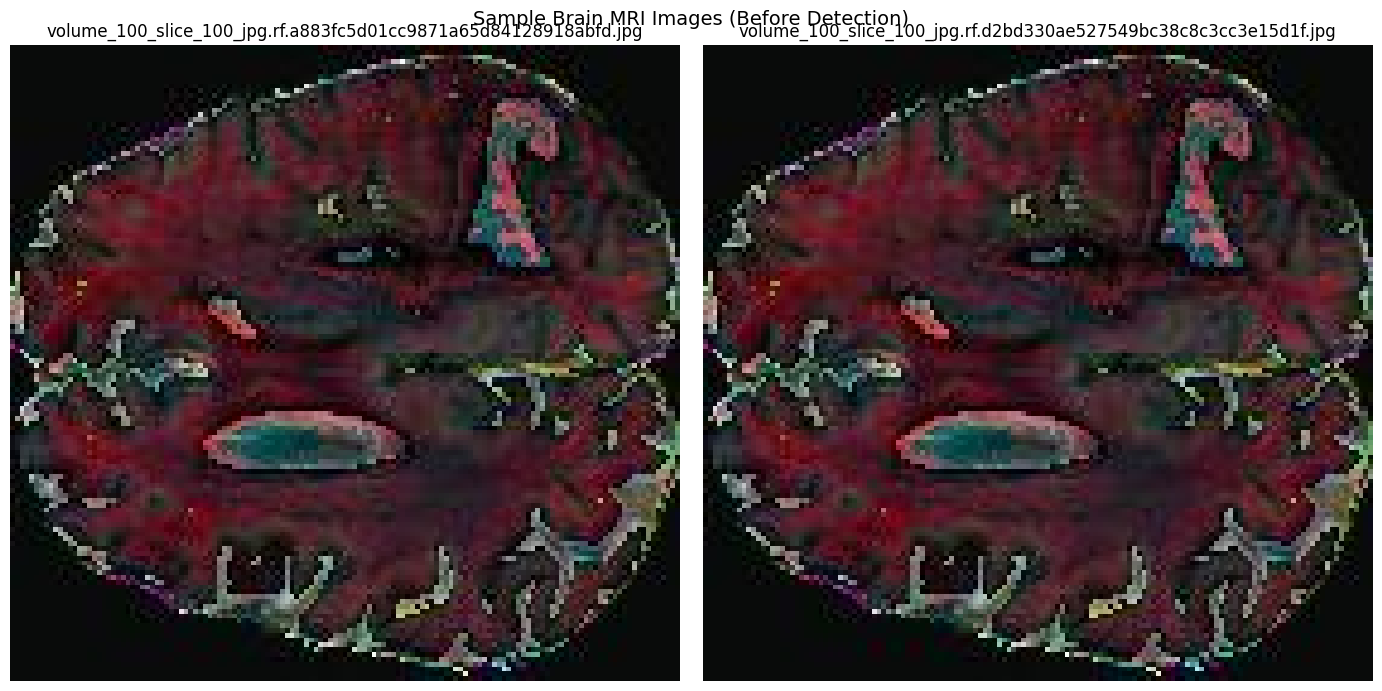

In [76]:
# ============================================
# LOAD SAMPLE BRAIN MRI IMAGES FROM DATASET
# ============================================

# Grab the first 2 images from the train/images folder
# (already downloaded as part of the Roboflow dataset)

train_img_dir = os.path.join(DATASET_DIR, 'train', 'images')

all_images = [
    os.path.join(train_img_dir, f)
    for f in sorted(os.listdir(train_img_dir))
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

sample_images = all_images[:2]   # take first 2, same as traffic example

for path in sample_images:
    print(f"✅ Found: {path}")

# ============================================
# DISPLAY SAMPLE IMAGES
# ============================================

fig, axes = plt.subplots(1, len(sample_images),
                         figsize=(7 * len(sample_images), 7))
if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(os.path.basename(img_path), fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Brain MRI Images (Before Detection)', fontsize=14)
plt.tight_layout()
plt.show()

## Run Detection & Visualize Results


0: 608x640 (no detections), 11.0ms
1: 608x640 (no detections), 11.0ms
Speed: 1.8ms preprocess, 11.0ms inference, 0.2ms postprocess per image at shape (1, 3, 608, 640)

Image: volume_100_slice_100_jpg.rf.a883fc5d01cc9871a65d84128918abfd.jpg

📦 Detections found: 0
  ⚠️  No detections above confidence threshold.


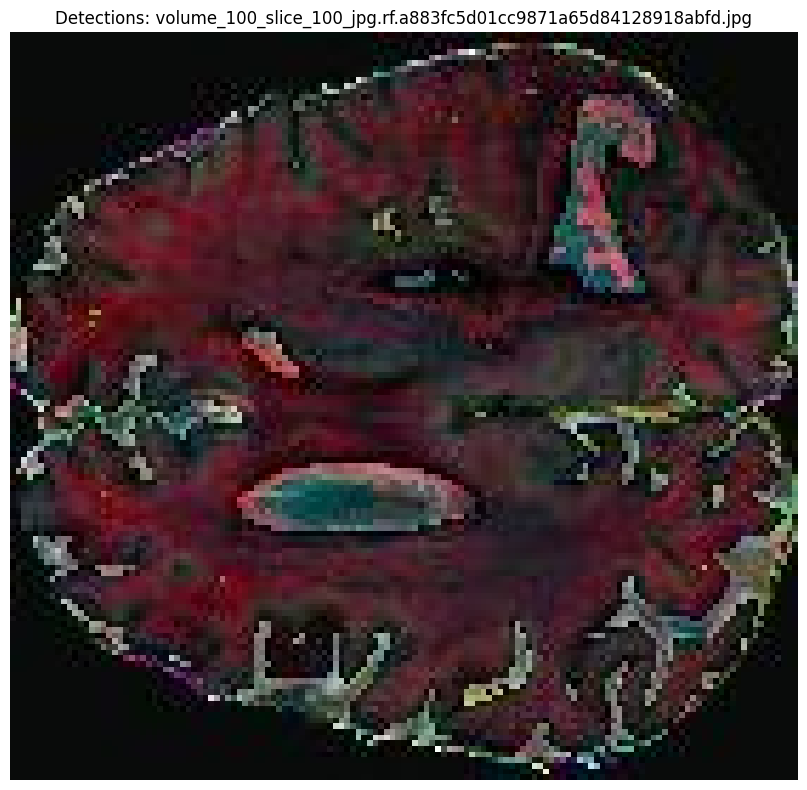


Image: volume_100_slice_100_jpg.rf.d2bd330ae527549bc38c8c3cc3e15d1f.jpg

📦 Detections found: 0
  ⚠️  No detections above confidence threshold.


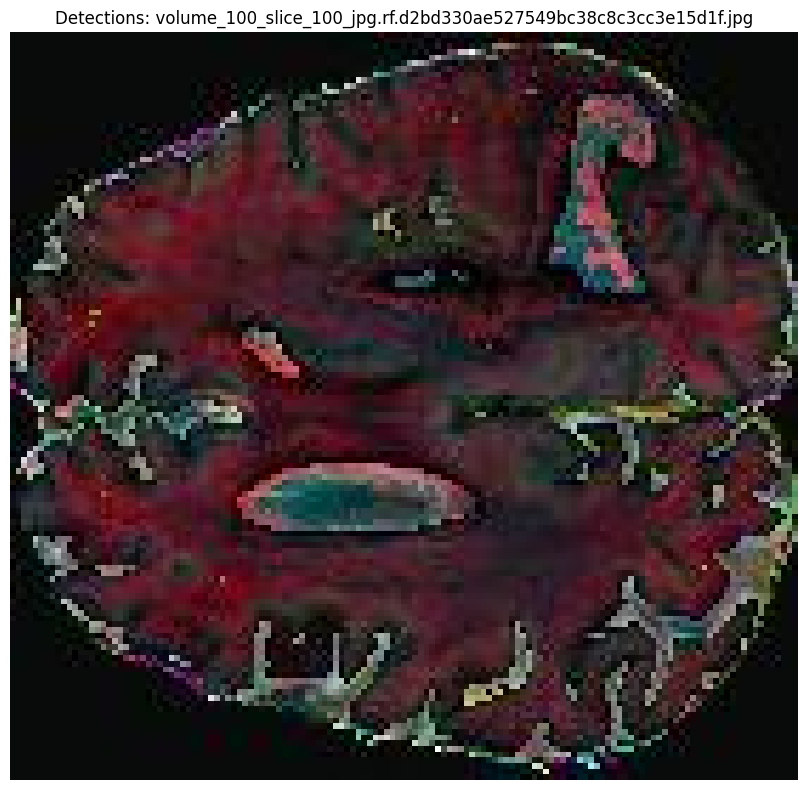

In [77]:
# ============================================
# RUN DETECTION ON SAMPLE BRAIN MRI IMAGES
# ============================================

# conf=0.25 means only show detections with >25% confidence.

results = model_pretrained(sample_images, conf=0.25)

# Display results with detailed breakdown
for i, result in enumerate(results):
    print(f"\n{'=' * 60}")
    print(f"Image: {os.path.basename(sample_images[i])}")
    print(f"{'=' * 60}")

    boxes = result.boxes
    print(f"\n📦 Detections found: {len(boxes)}")

    if len(boxes) == 0:
        print("  ⚠️  No detections above confidence threshold.")
    else:
        print(f"{'─' * 55}")
        print(f"{'Class':<20} {'Confidence':<12} {'Box (x1,y1,x2,y2)'}")
        print(f"{'─' * 55}")
        for box in boxes:
            cls_id    = int(box.cls[0])
            conf      = float(box.conf[0])
            xyxy      = box.xyxy[0].cpu().numpy()
            class_name = model_pretrained.names[cls_id]   # COCO class name
            print(f"{class_name:<20} {conf:<12.3f} "
                  f"[{xyxy[0]:.0f}, {xyxy[1]:.0f}, {xyxy[2]:.0f}, {xyxy[3]:.0f}]")

    # Plot with bounding boxes (or plain image if no detections)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    annotated = result.plot()          # Returns BGR numpy array
    ax.imshow(annotated[..., ::-1])   # Convert BGR → RGB
    ax.set_title(f"Detections: {os.path.basename(sample_images[i])}", fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Explore Confidence Thresholds

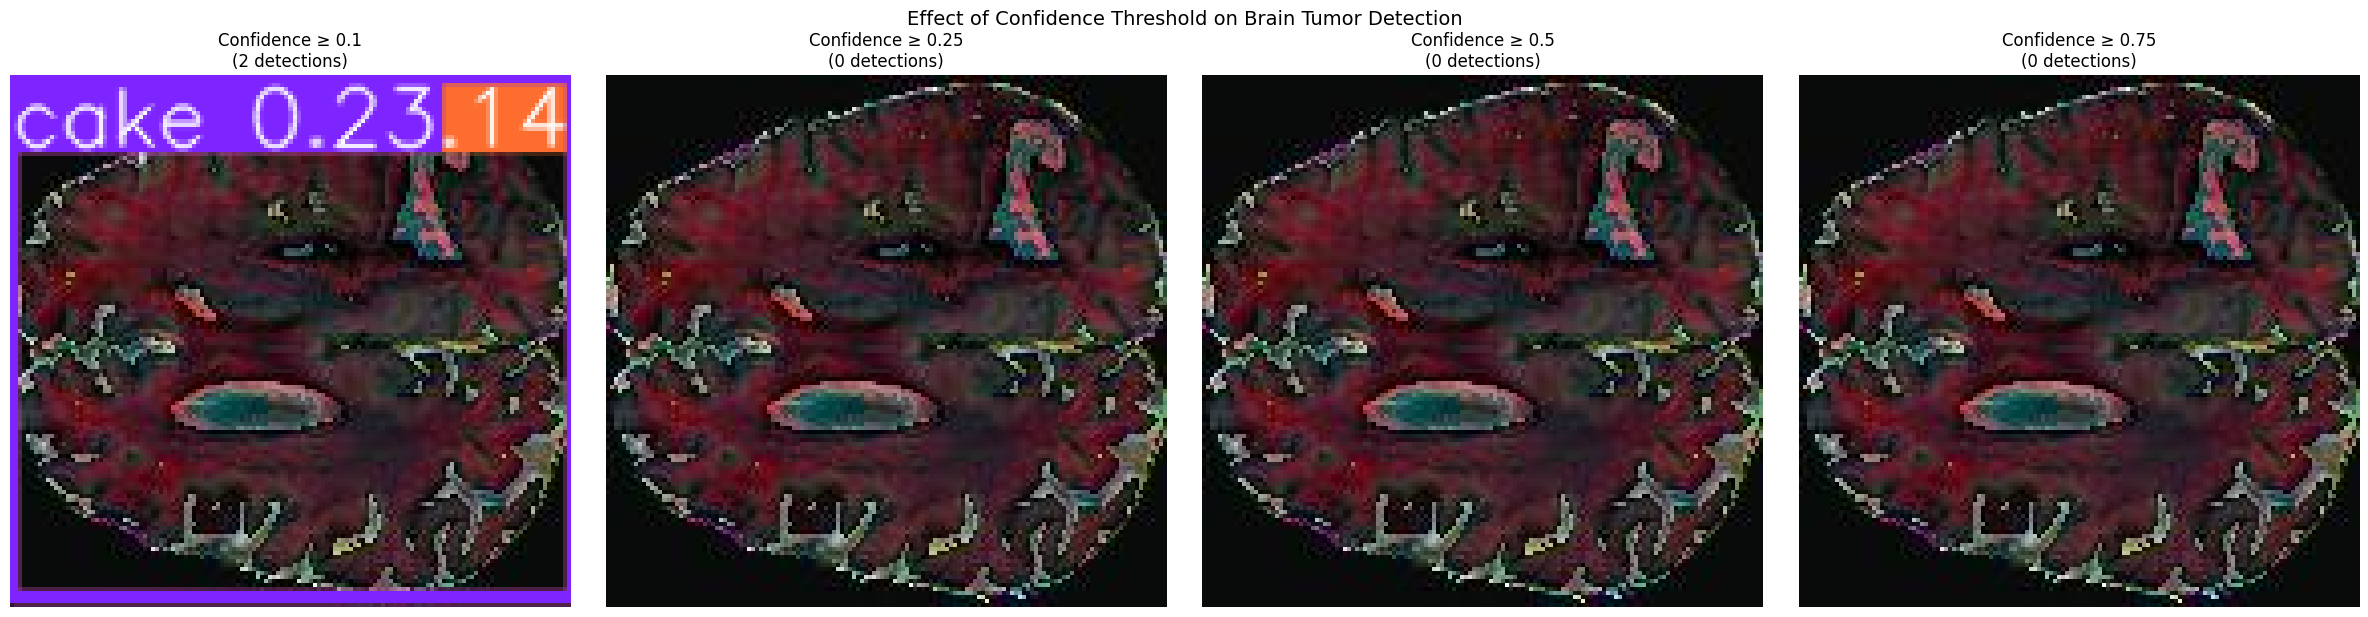

In [78]:
# ============================================
# CONFIDENCE THRESHOLD COMPARISON
# ============================================

test_image = sample_images[0]  # Use first brain MRI sample
thresholds = [0.10, 0.25, 0.50, 0.75]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, thresh in zip(axes, thresholds):
    result = model_pretrained(test_image, conf=thresh, verbose=False)
    annotated = result[0].plot()
    ax.imshow(annotated[..., ::-1])
    n_detections = len(result[0].boxes)
    ax.set_title(f"Confidence ≥ {thresh}\n({n_detections} detections)",
                 fontsize=12)
    ax.axis('off')

plt.suptitle('Effect of Confidence Threshold on Brain Tumor Detection',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



#### 💡 Key Insight for Brain Tumor Detection:
  Low threshold (0.10):  More detections, higher risk of false positives
  
  High threshold (0.75): Fewer detections, only high-confidence predictions
  
  • Clinical screening  → lower threshold (don't miss any potential tumors!)
  
  • Diagnosis support   → higher threshold (precision matters more)

### 640 Image Size & 16 Batch Size

In [79]:
# ============================================
# FINE-TUNE YOLOv8 ON BRAIN TUMOR DATASET
# ============================================

data_yaml = os.path.join(DATASET_DIR, 'data.yaml')

results = model_pretrained.train(
    data    = data_yaml,       # Path to dataset config
    epochs  = 25,              # Minimum required — increase to 50+ for better results
    imgsz   = 640,             # Standard YOLO input size
    batch   = 16,              # Reduce to 8 if you get out-of-memory errors
    name    = 'brain_tumor_v1',# Run name — saved under runs/detect/
    patience= 10,              # Early stopping if no improvement after 10 epochs
    verbose = True,
)

print("\n✅ Training complete!")
print(f"📁 Results saved to: {results.save_dir}")

Ultralytics 8.4.19  Python-3.13.7 torch-2.10.0.dev20251124+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Sepeh\source\repos\mini-project-7\notebooks\-Brain-Tumor-Detection-1\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_v12, nbs=64, nms=Fa

In [80]:
# ============================================
# EVALUATE TRAINED MODEL ON VALIDATION SET
# ============================================

trained_model = YOLO(f"{results.save_dir}/weights/best.pt")

metrics = trained_model.val(
    data    = data_yaml,
    split   = 'val',
    verbose = True,
    # add 50-95 mAP for more insight
    
)

# ============================================
# PRINT EVALUATION METRICS
# ============================================

print("\n" + "=" * 50)
print("        📊 MODEL EVALUATION RESULTS")
print("=" * 50)

print(f"\n{'Metric':<25} {'Value'}")
print(f"{'─' * 40}")
print(f"  {'mAP@50':<23} {metrics.box.map50:.4f}")
print(f"  {'mAP@50-95':<23} {metrics.box.map:.4f}")
print(f"  {'Precision':<23} {metrics.box.mp:.4f}")
print(f"  {'Recall':<23} {metrics.box.mr:.4f}")
print(f"{'─' * 40}")

Ultralytics 8.4.19  Python-3.13.7 torch-2.10.0.dev20251124+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 100.330.4 MB/s, size: 5.5 KB)
val: Scanning C:\Users\Sepeh\source\repos\mini-project-7\notebooks\-Brain-Tumor-Detection-1\valid\labels.cache... 1980 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1980/1980 593.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 124/124 18.7it/s 6.6s0.2s
                   all       1980       4380      0.866       0.71      0.772      0.488
                label0       1246       1246      0.817      0.636      0.704      0.394
                label1       1944       1944      0.906      0.814      0.867       0.61
                label2       1190       1190      0.877       0.68      0.746       0.46
Speed: 0.6ms preprocess, 0.7ms inference, 0

In [81]:
# Helper function to help remap model.names if the dataset uses generic labels like 'label0', 'label1', etc.
def apply_name_remap(model, remap_dict):
    """
    Update class names used by YOLO plotting.
    Returns original names so they can be restored.
    """

    # YOLO stores the mutable names here
    original_names = dict(model.model.names)

    new_names = {}
    for k, v in original_names.items():
        new_names[k] = remap_dict.get(v, v)

    model.model.names = new_names

    return original_names


          PER-CLASS METRICS

Class                AP@50        AP@50-95     Precision    Recall
───────────────────────────────────────────────────────────────
  glioma             0.7035       0.3936       0.8165       0.6357
  meningioma         0.8668       0.6100       0.9063       0.8143
  pituitary          0.7460       0.4604       0.8766       0.6802
───────────────────────────────────────────────────────────────


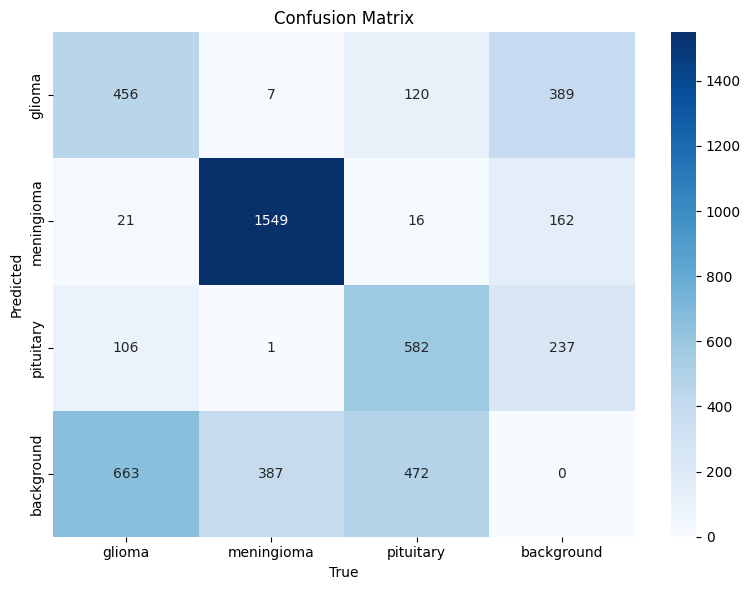

In [82]:
# ============================================
# PER-CLASS METRICS
# ============================================

print("\n" + "=" * 60)
print("          PER-CLASS METRICS")
print("=" * 60)
print(f"\n{'Class':<20} {'AP@50':<12} {'AP@50-95':<12} {'Precision':<12} {'Recall'}")
print(f"{'─' * 63}")

for i, class_name in trained_model.names.items():

    # remap label0 -> tumor name
    class_name = TUMOR_LABEL_REMAP.get(class_name, class_name)

    ap50      = metrics.box.ap50[i]
    ap50_95   = metrics.box.ap[i]
    precision = metrics.box.p[i]
    recall    = metrics.box.r[i]

    print(f"  {class_name:<18} {ap50:<12.4f} {ap50_95:<12.4f} {precision:<12.4f} {recall:.4f}")

print(f"{'─' * 63}")


# ============================================
# CONFUSION MATRIX
# ============================================

import seaborn as sns
import numpy as np

cm = metrics.confusion_matrix.matrix

# get model class names
model_names = trained_model.names

# remap label names
class_names = [
    TUMOR_LABEL_REMAP.get(name, name)
    for name in model_names.values()
]

# YOLO confusion matrix includes background as last class
class_names = class_names + ["background"]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("True")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

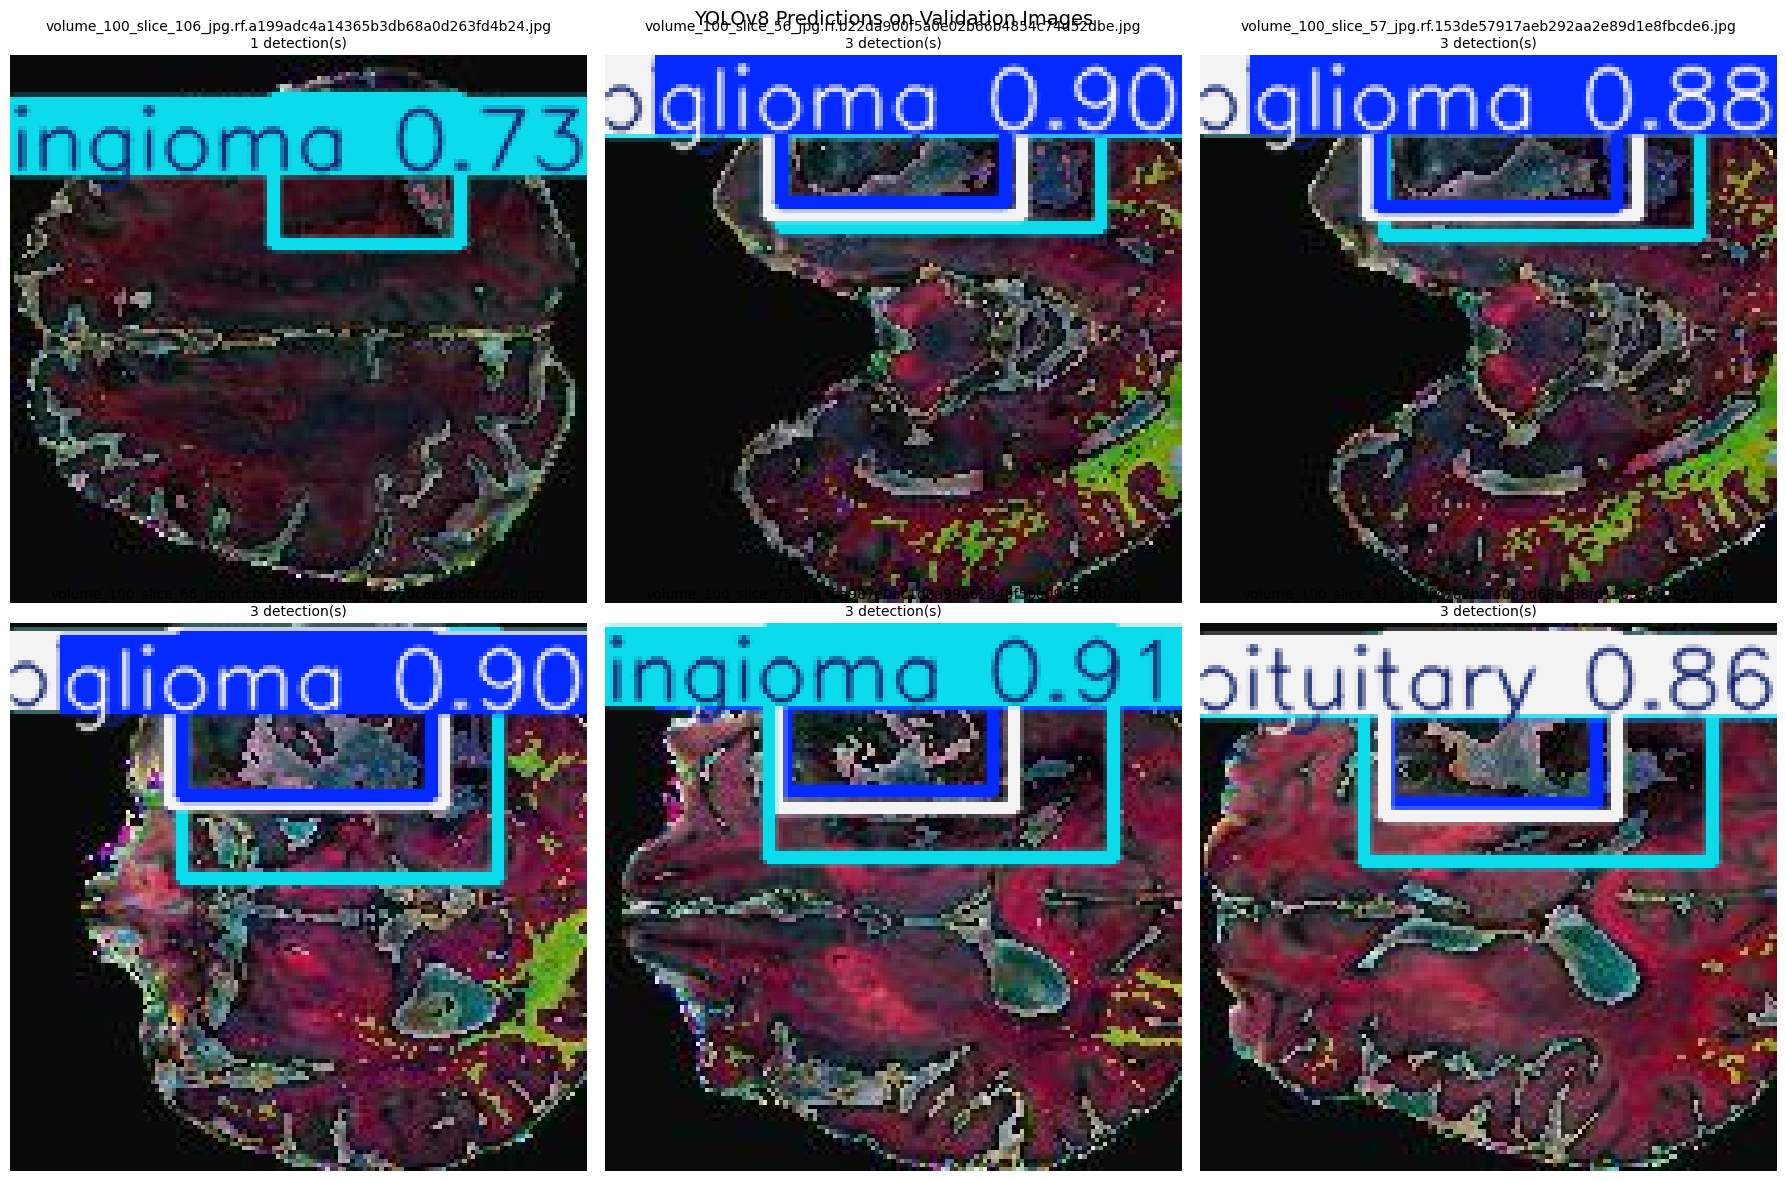

In [83]:
# ============================================
# VISUALIZE 6 PREDICTIONS ON VALIDATION IMAGES (FIXED LABELS)
# ============================================

val_img_dir = os.path.join(DATASET_DIR, "valid", "images")

val_images = [
    os.path.join(val_img_dir, f)
    for f in sorted(os.listdir(val_img_dir))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:6]

# Build a remapped names dict keyed by class index (0..nc-1)
# trained_model.names is read-only but we can read it
remapped_names = {
    i: TUMOR_LABEL_REMAP.get(name, name)
    for i, name in trained_model.names.items()
}

results_val = trained_model(val_images, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results_val, val_images):
    # Force the result object to use your remapped names
    result.names = remapped_names

    annotated = result.plot()  # now plots with your names
    ax.imshow(annotated[..., ::-1])
    n = len(result.boxes)
    ax.set_title(f"{os.path.basename(img_path)}\n{n} detection(s)", fontsize=10)
    ax.axis("off")

plt.suptitle("YOLOv8 Predictions on Validation Images", fontsize=14)
plt.tight_layout()
plt.show()

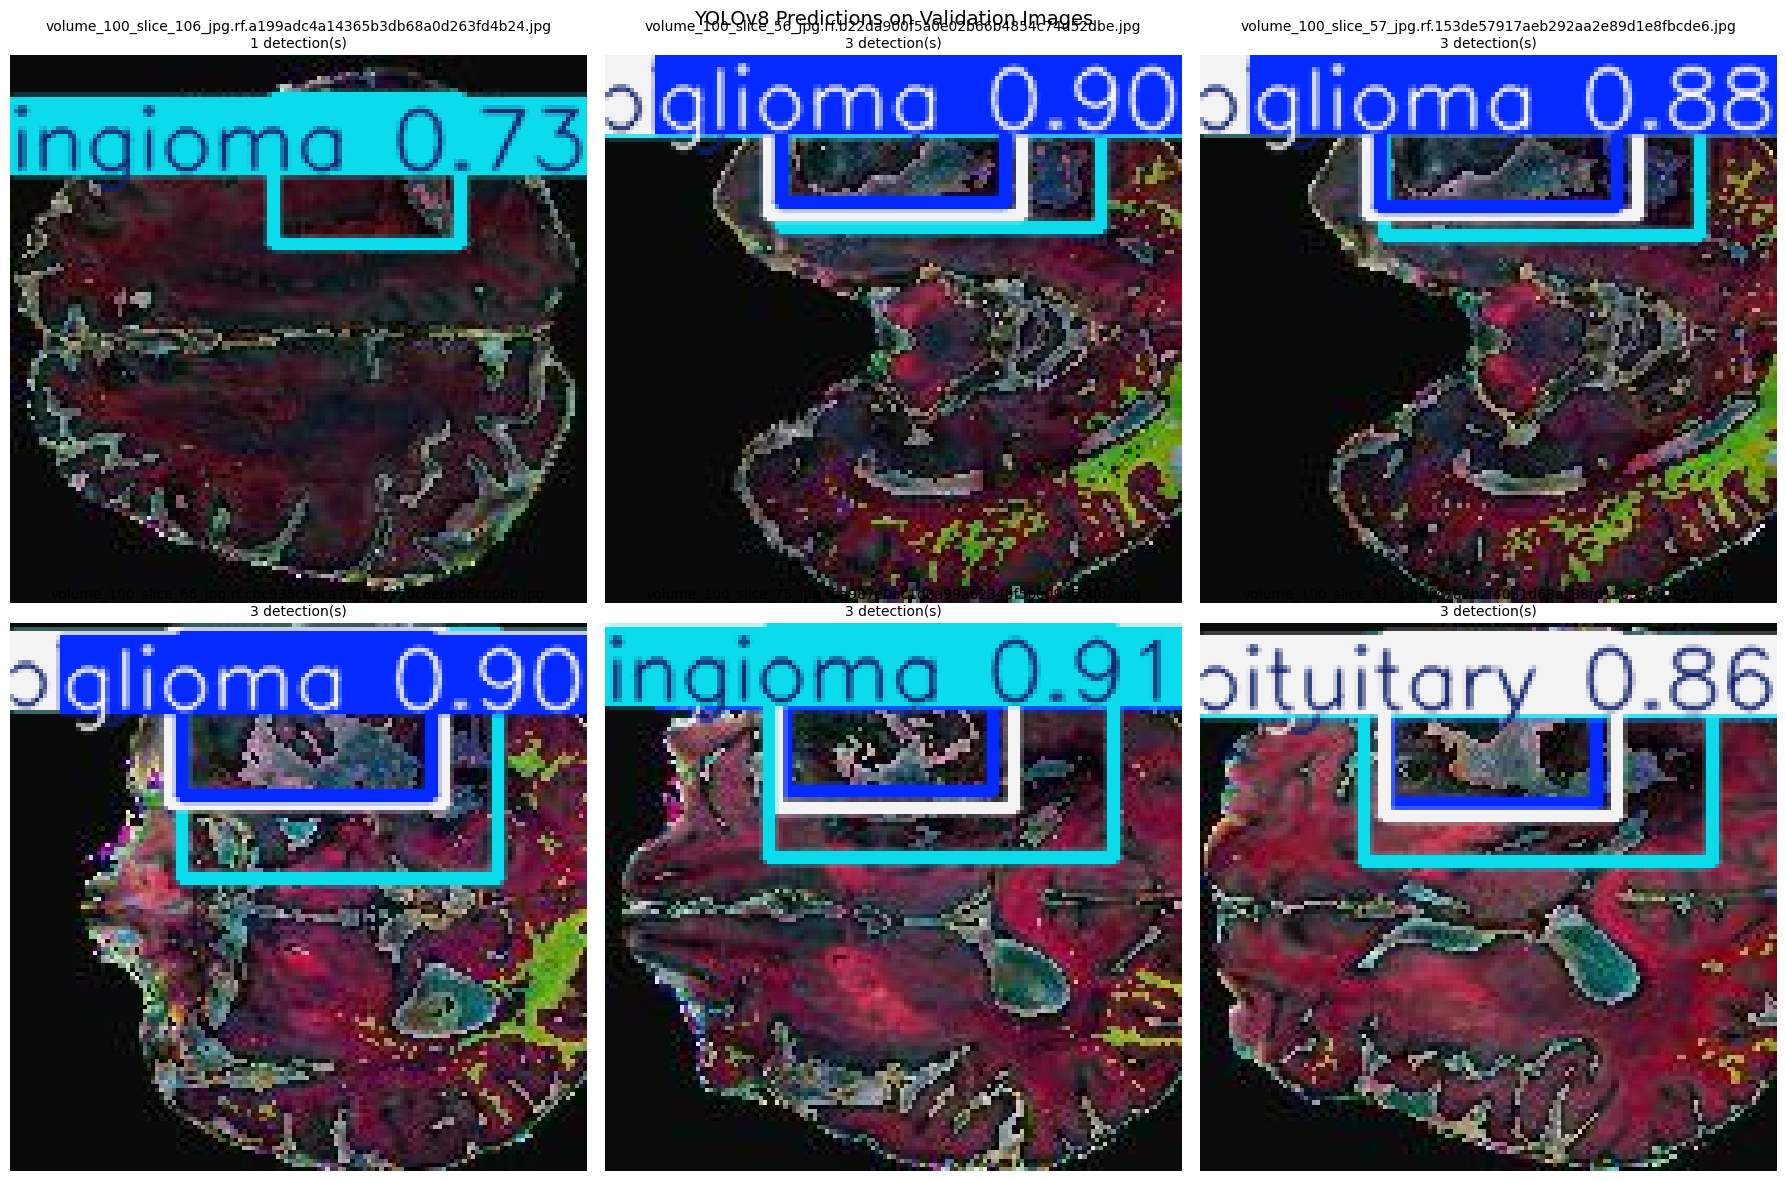

In [84]:
# ============================================
# VISUALIZE 6 PREDICTIONS ON VALIDATION IMAGES (FIXED LABELS)
# ============================================

val_img_dir = os.path.join(DATASET_DIR, "valid", "images")

val_images = [
    os.path.join(val_img_dir, f)
    for f in sorted(os.listdir(val_img_dir))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:6]

# Build remapped label dictionary
remapped_names = {
    i: TUMOR_LABEL_REMAP.get(name, name)
    for i, name in trained_model.names.items()
}

results_val = trained_model(val_images, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results_val, val_images):

    # Override labels used by YOLO plotting
    result.names = remapped_names

    annotated = result.plot()

    ax.imshow(annotated[..., ::-1])
    n = len(result.boxes)

    ax.set_title(
        f"{os.path.basename(img_path)}\n{n} detection(s)",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle("YOLOv8 Predictions on Validation Images", fontsize=14)
plt.tight_layout()
plt.show()

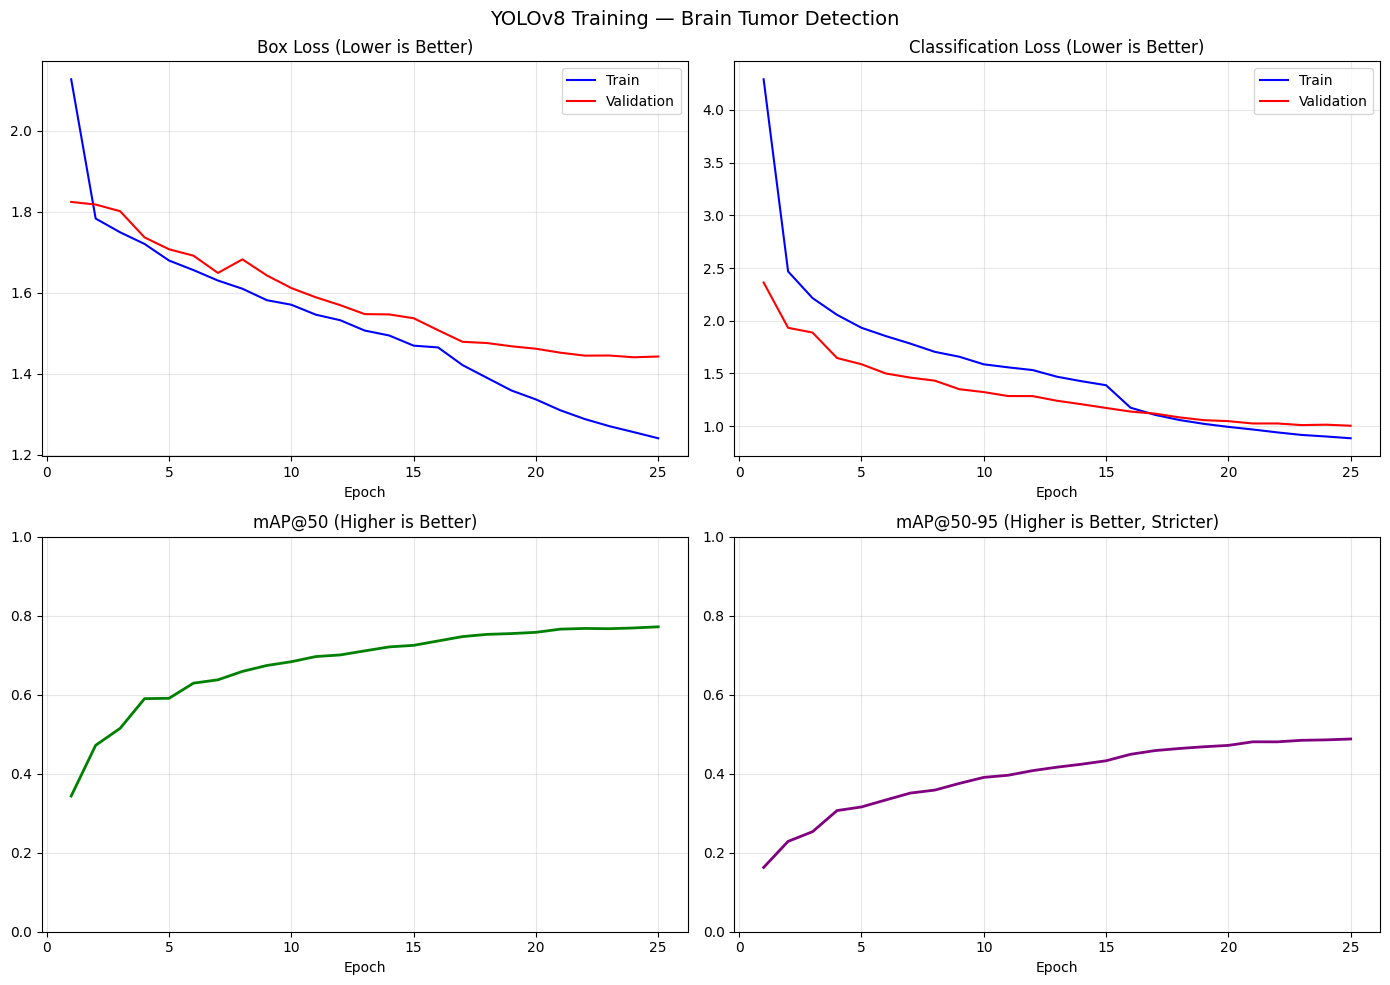


 Final Metrics:
  mAP@50:    0.7722
  mAP@50-95: 0.4881
  Box loss:  1.4423
  Cls loss:  1.0042


In [85]:
# ============================================
# TRAINING CURVES — LOSS & mAP OVER EPOCHS
# ============================================

import pandas as pd

results_csv = os.path.join(results.save_dir, 'results.csv')
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Box loss
    axes[0, 0].plot(df['epoch'], df['train/box_loss'],
                    label='Train', color='blue')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'],
                    label='Validation', color='red')
    axes[0, 0].set_title('Box Loss (Lower is Better)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Classification loss
    axes[0, 1].plot(df['epoch'], df['train/cls_loss'],
                    label='Train', color='blue')
    axes[0, 1].plot(df['epoch'], df['val/cls_loss'],
                    label='Validation', color='red')
    axes[0, 1].set_title('Classification Loss (Lower is Better)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # mAP@50
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'],
                    color='green', linewidth=2)
    axes[1, 0].set_title('mAP@50 (Higher is Better)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)

    # mAP@50-95
    axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'],
                    color='purple', linewidth=2)
    axes[1, 1].set_title('mAP@50-95 (Higher is Better, Stricter)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('YOLOv8 Training — Brain Tumor Detection', fontsize=14)
    plt.tight_layout()
    plt.show()

    last = df.iloc[-1]
    print("\n Final Metrics:")
    print("=" * 40)
    print(f"  mAP@50:    {last['metrics/mAP50(B)']:.4f}")
    print(f"  mAP@50-95: {last['metrics/mAP50-95(B)']:.4f}")
    print(f"  Box loss:  {last['val/box_loss']:.4f}")
    print(f"  Cls loss:  {last['val/cls_loss']:.4f}")
else:
    print(" results.csv not found.")

### 416 Image Size & 8 Batch Size

In [ ]:
# ============================================
# FINE-TUNE YOLOv26 ON BRAIN TUMOR DATASET
# ============================================

model_pretrained = YOLO('yolo26n.pt')  # Reload to reset overrides

data_yaml = os.path.join(DATASET_DIR, 'data.yaml')
results = model_pretrained.train(
    data    = data_yaml,
    epochs  = 25,
    imgsz   = 416,
    batch   = 8,
    name    = 'brain_tumor_v2',  # Use a new name to avoid conflicts with the previous run
    patience= 10,
    verbose = True,
)

print("\n✅ Training complete!")
print(f"📁 Results saved to: {results.save_dir}")

Ultralytics 8.4.19  Python-3.13.7 torch-2.10.0.dev20251124+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Sepeh\source\repos\mini-project-7\notebooks\-Brain-Tumor-Detection-1\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_v2, nbs=64, nms=Fals

In [ ]:
# ============================================
# EVALUATE TRAINED MODEL ON VALIDATION SET
# ============================================

trained_model = YOLO(f"{results.save_dir}/weights/best.pt")

metrics = trained_model.val(
    data    = data_yaml,
    split   = 'val',
    verbose = True,
    # add 50-95 mAP for more insight
    
)

# ============================================
# PRINT EVALUATION METRICS
# ============================================

print("\n" + "=" * 50)
print("        📊 MODEL EVALUATION RESULTS")
print("=" * 50)

print(f"\n{'Metric':<25} {'Value'}")
print(f"{'─' * 40}")
print(f"  {'mAP@50':<23} {metrics.box.map50:.4f}")
print(f"  {'mAP@50-95':<23} {metrics.box.map:.4f}")
print(f"  {'Precision':<23} {metrics.box.mp:.4f}")
print(f"  {'Recall':<23} {metrics.box.mr:.4f}")
print(f"{'─' * 40}")

In [ ]:
# ============================================
# PER-CLASS METRICS
# ============================================

print("\n" + "=" * 60)
print("          PER-CLASS METRICS")
print("=" * 60)
print(f"\n{'Class':<20} {'AP@50':<12} {'AP@50-95':<12} {'Precision':<12} {'Recall'}")
print(f"{'─' * 63}")

for i, class_name in trained_model.names.items():

    # remap label0 -> tumor name
    class_name = TUMOR_LABEL_REMAP.get(class_name, class_name)

    ap50      = metrics.box.ap50[i]
    ap50_95   = metrics.box.ap[i]
    precision = metrics.box.p[i]
    recall    = metrics.box.r[i]

    print(f"  {class_name:<18} {ap50:<12.4f} {ap50_95:<12.4f} {precision:<12.4f} {recall:.4f}")

print(f"{'─' * 63}")


# ============================================
# CONFUSION MATRIX
# ============================================

import seaborn as sns
import numpy as np

cm = metrics.confusion_matrix.matrix

# get model class names
model_names = trained_model.names

# remap label names
class_names = [
    TUMOR_LABEL_REMAP.get(name, name)
    for name in model_names.values()
]

# YOLO confusion matrix includes background as last class
class_names = class_names + ["background"]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("True")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# VISUALIZE 6 PREDICTIONS ON VALIDATION IMAGES (FIXED LABELS)
# ============================================

val_img_dir = os.path.join(DATASET_DIR, "valid", "images")

val_images = [
    os.path.join(val_img_dir, f)
    for f in sorted(os.listdir(val_img_dir))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:6]

# Build a remapped names dict keyed by class index (0..nc-1)
# trained_model.names is read-only but we can read it
remapped_names = {
    i: TUMOR_LABEL_REMAP.get(name, name)
    for i, name in trained_model.names.items()
}

results_val = trained_model(val_images, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results_val, val_images):
    # Force the result object to use your remapped names
    result.names = remapped_names

    annotated = result.plot()  # now plots with your names
    ax.imshow(annotated[..., ::-1])
    n = len(result.boxes)
    ax.set_title(f"{os.path.basename(img_path)}\n{n} detection(s)", fontsize=10)
    ax.axis("off")

plt.suptitle("YOLOv8 Predictions on Validation Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# VISUALIZE 6 PREDICTIONS ON VALIDATION IMAGES (FIXED LABELS)
# ============================================

val_img_dir = os.path.join(DATASET_DIR, "valid", "images")

val_images = [
    os.path.join(val_img_dir, f)
    for f in sorted(os.listdir(val_img_dir))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:6]

# Build remapped label dictionary
remapped_names = {
    i: TUMOR_LABEL_REMAP.get(name, name)
    for i, name in trained_model.names.items()
}

results_val = trained_model(val_images, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results_val, val_images):

    # Override labels used by YOLO plotting
    result.names = remapped_names

    annotated = result.plot()

    ax.imshow(annotated[..., ::-1])
    n = len(result.boxes)

    ax.set_title(
        f"{os.path.basename(img_path)}\n{n} detection(s)",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle("YOLOv8 Predictions on Validation Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# TRAINING CURVES — LOSS & mAP OVER EPOCHS
# ============================================

import pandas as pd

results_csv = os.path.join(results.save_dir, 'results.csv')
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Box loss
    axes[0, 0].plot(df['epoch'], df['train/box_loss'],
                    label='Train', color='blue')
    axes[0, 0].plot(df['epoch'], df['val/box_loss'],
                    label='Validation', color='red')
    axes[0, 0].set_title('Box Loss (Lower is Better)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Classification loss
    axes[0, 1].plot(df['epoch'], df['train/cls_loss'],
                    label='Train', color='blue')
    axes[0, 1].plot(df['epoch'], df['val/cls_loss'],
                    label='Validation', color='red')
    axes[0, 1].set_title('Classification Loss (Lower is Better)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # mAP@50
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'],
                    color='green', linewidth=2)
    axes[1, 0].set_title('mAP@50 (Higher is Better)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)

    # mAP@50-95
    axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'],
                    color='purple', linewidth=2)
    axes[1, 1].set_title('mAP@50-95 (Higher is Better, Stricter)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('YOLOv8 Training — Brain Tumor Detection', fontsize=14)
    plt.tight_layout()
    plt.show()

    last = df.iloc[-1]
    print("\n Final Metrics:")
    print("=" * 40)
    print(f"  mAP@50:    {last['metrics/mAP50(B)']:.4f}")
    print(f"  mAP@50-95: {last['metrics/mAP50-95(B)']:.4f}")
    print(f"  Box loss:  {last['val/box_loss']:.4f}")
    print(f"  Cls loss:  {last['val/cls_loss']:.4f}")
else:
    print(" results.csv not found.")

# Model Evaluation and Analysis

## Dataset Class Balance and Its Impact on Model Performance

The performance results show noticeable differences between the three tumor classes:

| Class | AP@50 | AP@50–95 | Precision | Recall |
|------|------|------|------|------|
| glioma | 0.7157 | 0.4235 | 0.8276 | 0.6340 |
| meningioma | 0.8703 | 0.6150 | 0.9076 | 0.8143 |
| pituitary | 0.7692 | 0.4833 | 0.8931 | 0.6908 |

From these results, meningioma is clearly the best-performing class, achieving the highest scores across all metrics:

- AP@50 = **0.8703**
- Precision = **0.9076**
- Recall = **0.8143**

In contrast, glioma shows the weakest performance, particularly in recall:

- Recall = 0.6340, meaning roughly 36% of glioma tumors may be missed by the model.

This difference suggests the dataset may be imbalanced, where certain tumor types appear more frequently or have clearer visual patterns. If the training dataset contains more examples of meningioma tumors, the model will naturally learn that class more effectively.

Another possible explanation is that glioma tumors may have more irregular shapes or less consistent visual features, making them harder for the model to detect.

From a medical perspective, this imbalance is important because glioma tumors are often aggressive brain tumors, and missing them could delay treatment. Improving the detection performance for glioma should therefore be a priority.

Possible strategies to address dataset imbalance include:

- Collecting more MRI scans of underrepresented tumor types  
- Applying targeted data augmentation for rare classes  
- Using class-weighted training to reduce bias toward common classes  

---

## 2. Confidence Threshold Comparison for Medical Applications

The model predictions are filtered using a confidence threshold, which determines the minimum probability required before a detection is accepted.

Different thresholds influence the trade-off between precision and recall:

| Threshold | Effect |
|--------|--------|
| **0.25** | Higher recall, more detections, but more false positives |
| **0.50** | Balanced precision and recall |
| **0.75+** | Higher precision but increased false negatives |

Looking at the current results, the model already achieves high precision values:

- Glioma precision = **0.8276**
- Meningioma precision = **0.9076**
- Pituitary precision = **0.8931**

However, recall is noticeably lower, especially for glioma (**0.6340**). This means the model is more conservative in detecting tumors, potentially missing real cases.

In a medical context, false negatives are far more dangerous than false positives. If the system fails to detect a tumor, the patient may not receive timely treatment.

Because of this, a lower confidence threshold (around 0.30–0.40) would likely be more appropriate for clinical use. This would increase recall and reduce the risk of missing tumors, even if it introduces more false positives that doctors must review.

---

## 3. Classes the Model Struggles With

Based on the metrics, the model struggles most with glioma tumors.

Key indicators include:

- Lowest AP@50 (**0.7157**)  
- Lowest AP@50–95 (**0.4235**)  
- Lowest recall (**0.6340**)  

This suggests the model misses a significant number of glioma cases compared to other tumor types.

There are several possible explanations for this:

**Visual complexity:**

Glioma tumors often have irregular shapes and diffuse boundaries in MRI scans, which can make them harder to localize.

**Dataset imbalance**

If the dataset contains fewer glioma examples than meningioma tumors, the model will naturally perform worse on this class.

**Similar visual features**

Glioma tumors may share visual characteristics with surrounding brain tissue, making them harder to distinguish.

From a real-world medical perspective, this is concerning because gliomas are often high-grade malignant tumors that require early detection. Improving glioma detection performance should therefore be a key priority.

---

## 4. False Positives vs False Negatives in the Medical Context

In medical AI systems, the impact of errors must be carefully evaluated.

### False Positives

A false positive occurs when the model predicts a tumor where none exists.

Potential consequences include:

- Additional review by a radiologist  
- Possible follow-up imaging  
- Increased clinical workload  

However, these errors are generally manageable because medical professionals can verify the prediction.

### False Negatives

A false negative occurs when the model fails to detect a real tumor.

Given the recall values:

- Glioma recall = **0.6340**
- Pituitary recall = **0.6908**
- Meningioma recall = **0.8143**

The model is currently **missing some tumors**, especially glioma.

In a real clinical scenario, a false negative could mean:

- A tumor goes undetected  
- Treatment is delayed  
- The disease progresses before diagnosis

Because of this, false negatives are significantly more dangerous than false positives in medical imaging systems.

For this reason, the system should prioritize higher recall, even if it results in additional false positives that doctors must review.

---

## 5. Business Recommendation: Is the Model Ready for Clinical Deployment?

The model demonstrates promising performance, particularly for meningioma tumors, where precision and recall are both high. However, the current results suggest that the model is not yet ready for direct clinical deployment.

The main concern is the relatively low recall for glioma tumors (0.6340), meaning the model may miss a substantial number of cases. In a medical environment, missing a tumor could have serious consequences for patient outcomes.

Instead, the model could be used as a clinical decision-support tool that assists radiologists by highlighting potential tumor regions.
